In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import torch
from transformers import AutoModelForSequenceClassification, AutoTokenizer 
from sklearn.metrics import confusion_matrix, accuracy_score, precision_score, recall_score, f1_score, classification_report
import seaborn as sns
import pickle

C:\Users\vanes\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\LocalCache\local-packages\Python312\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
C:\Users\vanes\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\LocalCache\local-packages\Python312\site-packages\threadpoolctl.py:1214: RuntimeWarning: 
Found Intel OpenMP ('libiomp') and LLVM OpenMP ('libomp') loaded at
the same time. Both libraries are known to be incompatible and this
can cause random crashes or deadlocks on Linux when loaded in the
same Python program.
Using threadpoolctl may cause crashes or deadlocks. For more
information and possible workarounds, please see
    https://github.com/joblib/threadpoolctl/blob/master/multiple_openmp.md

  warnings.warn(msg, RuntimeWarning)


In [ ]:
parties_list = ['CDU / CSU', 'GRÜNE', 'SPD', 'AfD', 'Die Linke', 'FDP']

# Main 

Modell laden 

In [4]:
model = AutoModelForSequenceClassification.from_pretrained("manifesto-project/manifestoberta-xlm-roberta-56policy-topics-context-2024-1-1", trust_remote_code=True)
model_name = 'manifesto-project/manifestoberta-xlm-roberta-56policy-topics-context-2024-1-1'
tokenizer = AutoTokenizer.from_pretrained("xlm-roberta-large")

Wahlomat klassifizieren

In [5]:
# Wahlomat-Thesen zu Manifesto Kategorien mappen, z.B. These 1 wird zu Welfare State Expansion gemappt 
# Wahlomat-Thesen laden
df_questions = pd.read_parquet("wahlomat_thesen_prep.parquet")

# Liste für Ergebnisse
results = []

for index, row in df_questions.iterrows():
    sentence = row["These"]
    context = sentence  # Nutzen der These selbst

    # Tokenisierung, Max len angepasst, muss im finetuning geändert werden 
    inputs = tokenizer(sentence, context, return_tensors="pt", max_length=17, padding="max_length", truncation=True)

    # Modellvorhersage
    logits = model(**inputs).logits
    probabilities = torch.softmax(logits, dim=1).tolist()[0]
    
    # Mapping der ID zur Policy-Kategorie
    probabilities = {model.config.id2label[index]: round(probability * 100, 2) for index, probability in enumerate(probabilities)}
    probabilities = dict(sorted(probabilities.items(), key=lambda item: item[1], reverse=True))
    
    # Beste Kategorie auswählen, Alternativ könnten hier auch alle Wahrscheinlichkeiten zum Vergleich genommen werden
    predicted_class = model.config.id2label[logits.argmax().item()]

    results.append({"These": sentence, "Predicted_Class": predicted_class, "Full_Probabilities": probabilities})

# Ergebnisse als DataFrame speichern
df_results = pd.DataFrame(results)
df_results.to_parquet("wahlomat_thesen_positionen_classified.parquet", index=False)

Parteien klassifizieren

In [9]:
df = pd.read_parquet("all_parties_text_combined_prep.parquet")

# Duplikate aus Thesen entfernen
df_filtered = df.dropna(subset=["These"]).drop_duplicates(subset=["Party", "These"])

all_results = []

# Klassifizierung der Thesen
for index, row in df_filtered.iterrows():
    party = row["Party"]
    thesis = row["These"]
    context = row["Text"]  
    #print("Started: ", index)

    # Vorhersage
    inputs = tokenizer(thesis, context, return_tensors="pt", max_length=512, padding="max_length", truncation=True)
    logits = model(**inputs).logits

    # Wahrscheinlichkeit berechnen 
    probabilities = torch.softmax(logits, dim=1).tolist()[0]
    predicted_class = model.config.id2label[logits.argmax().item()]
    #print("probability: ", index)

    row_dict = row.to_dict()  # Konvertiere die gesamte Zeile in ein Dictionary
    row_dict["Predicted_Class"] = predicted_class  # Füge die Vorhersage hinzu

    all_results.append(row_dict)

# Ergebnisse speichern
df_results = pd.DataFrame(all_results)

df_results.to_parquet("all_parties_text_combined_prep_classified.parquet", index=False)


Parteien und Wahlomat vergleichen

In [15]:
# Aus Klassifizierten Wahlomat und Partei Texten übereinstimmung analysieren
# Wahlomat-Daten
df_wahlomat = pd.read_parquet("wahlomat_thesen_positionen_classified.parquet")
df_wahlomat["Best_Policy_Category"] = df_wahlomat["Predicted_Class"]
df_wahlomat = df_wahlomat[["These", "Best_Policy_Category"]]

# Partei-Daten 
df_parties = pd.read_parquet("all_parties_text_combined_prep_classified.parquet")  # Enthält Positionen aller Parteien
df_parties["Policy_Category"] = df_parties["Predicted_Class"]

df_wahlomat["Best_Policy_Category"] = df_wahlomat["Best_Policy_Category"].astype(str).str[:3]
df_parties["Policy_Category"] = df_parties["Policy_Category"].astype(str).str[:3]

# Adjazenzmatrix laden
adj_matrix = pd.read_parquet("adjazenzmatrix.parquet")  # Stelle sicher, dass die Matrix als CSV gespeichert ist

def determine_position_adj(wahlomat_category, party_categories, adj_matrix):
    """
    Bestimmt die Haltung einer Partei basierend auf der Adjazenzmatrix.
    """
    for party_category in party_categories:
        if wahlomat_category not in adj_matrix.index or party_category not in adj_matrix.columns:
            continue  # Falls eine Kategorie nicht in der Matrix ist, ignorieren

        relationship = adj_matrix.at[wahlomat_category, party_category]

        if relationship == 1:
            return "stimme zu"
        elif relationship == -1:
            return "stimme nicht zu"

    return "neutral"

In [16]:
df_parties.head()

,Party,Chapter,These,Text,Text_no_stopwords,These_no_stopwords,Text_lemmatized,These_lemmatized,These_unique_words,Predicted_Class,Policy_Category
0,spd,1. Wir kämpfen für neues Wachstum und sichere ...,Wir wollen Energiepreise senken und zentrale E...,"Wir brauchen bezahlbare Energie, sonst geht un...",brauchen bezahlbare energie geht unternehmen d...,energiepreise senken zentrale erfolgsbranchen ...,brauchen bezahlbar Energie gehen Unternehmen D...,Energiepreise senken zentral erfolgsbranche st...,Energiepreise senken zentral erfolgsbranche st...,402 - Incentives,402
1,spd,1. Wir kämpfen für neues Wachstum und sichere ...,"Wir wollen, dass Unternehmen die besten Rahmen...",Wir können etwas tun für unsere Unternehmen un...,tun unternehmen wirtschaftsstandort schaffen d...,unternehmen besten rahmenbedingungen deutschla...,tun Unternehmen Wirtschaftsstandort schaffen D...,Unternehmen gut Rahmenbedingung Deutschland in...,Unternehmen gut Rahmenbedingung Deutschland in...,402 - Incentives,402
2,spd,1. Wir kämpfen für neues Wachstum und sichere ...,Wir wollen Bürokratie abbauen und Verfahren be...,Damit unsere Wirtschaft wieder schnell in Schw...,wirtschaft schnell schwung kommt müssen viele ...,bürokratie abbauen verfahren beschleunigen,Wirtschaft schnell Schwung kommen müssen viele...,Bürokratie abbauen Verfahren beschleunigen,Bürokratie abbauen Verfahren beschleunigen,303 - Governmental and Administrative Efficiency,303
3,spd,1. Wir kämpfen für neues Wachstum und sichere ...,"Wir wollen Innovationen ermöglichen, die Deuts...",Der viel beschworene Erfndergeist in Deutschla...,beschworene erfndergeist deutschland obersten ...,innovationen ermöglichen deutschland voranbringen,beschworen Erfndergeist Deutschland oberer Pri...,Innovation ermöglichen Deutschland voranbringen,Innovation ermöglichen Deutschland voranbringen,411 - Technology and Infrastructure,411
4,spd,2. Wir kämpfen für Made in Germany 2.0.,"Wir wollen eine stabile, breit aufgestellte un...","Unsere Unternehmen müssen sicher sein, dass si...",unternehmen müssen sicher klimaneutralität wei...,stabile breit aufgestellte zukunftsfähige wirt...,Unternehmen müssen sicher Klimaneutralität wei...,stabil breit aufgestellt zukunftsfähig Wirtschaft,stabil breit aufgestellt zukunftsfähig Wirtschaft,408 - Economic Goals,408


In [18]:
party_names = df_parties["Party"].unique()  # Alle Parteien im Datensatz

# Neuen DataFrame vorbereiten
df_wahlomat_results = df_wahlomat.copy()

for party in party_names:
    # Kategorien für die aktuelle Partei
    party_policy_set = set(df_parties[df_parties["Party"] == party]["Policy_Category"].unique())

    # Partei-Position für jede Wahlomat-These
    df_wahlomat_results[f"{party}_Model_Prediction"] = df_wahlomat_results["Best_Policy_Category"].apply(
        lambda cat: determine_position_adj(cat, party_policy_set, adj_matrix)
    )


df_wahlomat_results.to_parquet("all_parties_wahlomat_policy_comparison.parquet", index=False)

Ergebnisse visualisieren 

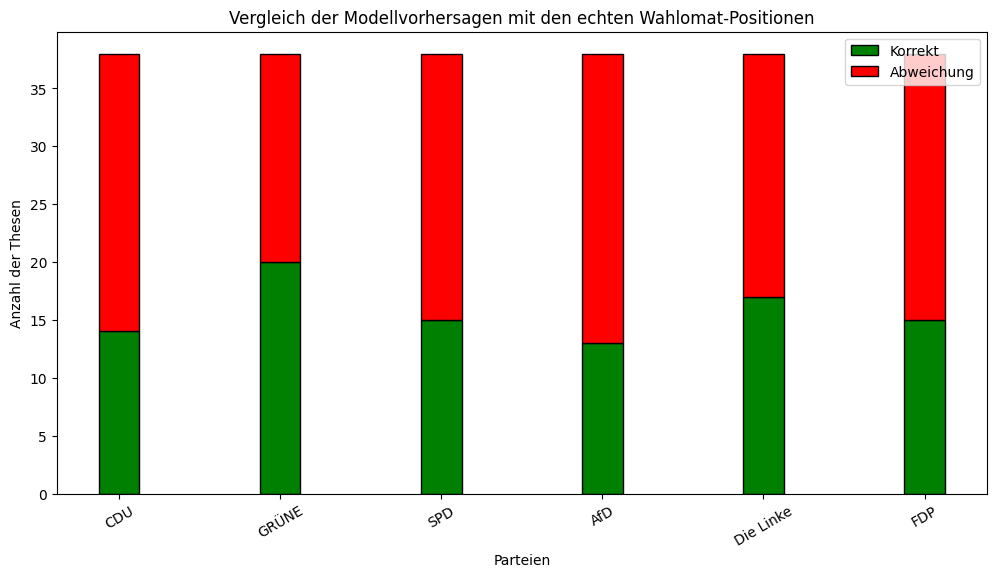

In [19]:
# Visualisieren der Ergebnisse

#  Wahlomat-Daten (Original // True Werte)
df_wahlomat_true = pd.read_parquet("wahlomat_thesen_positionen.parquet")  # Enthält tatsächliche Wahlomat-Antworten
df_wahlomat_true = df_wahlomat_true.rename(columns={"CDU / CSU": "CDU"})  
df_wahlomat_true = df_wahlomat_true[["These", "CDU", "GRÜNE", "SPD", "AfD", "Die Linke", "FDP"]]  # Nur relevante Spalten behalten

# Predictions für Parteien --> These entspricht hier der Wahlomat These
df_wahlomat_pred = pd.read_parquet("all_parties_wahlomat_policy_comparison.parquet")  # Modell-Vorhersagen der Parteien


df_comparison = df_wahlomat_true.merge(df_wahlomat_pred, on="These", how="left")

# Übereinstimmungen prüfen 
parties = ["CDU", "GRÜNE", "SPD", "AfD", "Die Linke", "FDP"]

party_model_mapping = {
    "CDU": "cdu_Model_Prediction",
    "GRÜNE": "gruene_Model_Prediction",
    "SPD": "spd_Model_Prediction",
    "AfD": "afd_Model_Prediction",
    "Die Linke": "linke_Model_Prediction",
    "FDP": "fdp_Model_Prediction"
}

metrics = []

# Übereinstimmungen prüfen 
results = {}
for party, model_col in party_model_mapping.items():
    if model_col in df_comparison.columns:  
        df_comparison[f"Abweichung_{party}"] = df_comparison.apply(
            lambda row: "Korrekt" if row[party] == row[model_col] else "Abweichung", axis=1
        )
        results[party] = df_comparison[f"Abweichung_{party}"].value_counts()

# Plot 
plt.figure(figsize=(12, 6))
bar_width = 0.25
index = range(len(parties))

correct_counts = [results[party].get("Korrekt", 0) for party in parties]
incorrect_counts = [results[party].get("Abweichung", 0) for party in parties]

plt.bar(index, correct_counts, bar_width, label="Korrekt", color="green", edgecolor="black")
plt.bar(index, incorrect_counts, bar_width, bottom=correct_counts, label="Abweichung", color="red", edgecolor="black")

plt.title("Vergleich der Modellvorhersagen mit den echten Wahlomat-Positionen")
plt.xlabel("Parteien")
plt.ylabel("Anzahl der Thesen")
plt.xticks(index, parties, rotation=30)
plt.legend(loc="upper right")
plt.show()

df_comparison.to_parquet("wahlomat_thesen_positionen_classified_comparison_plot.parquet")

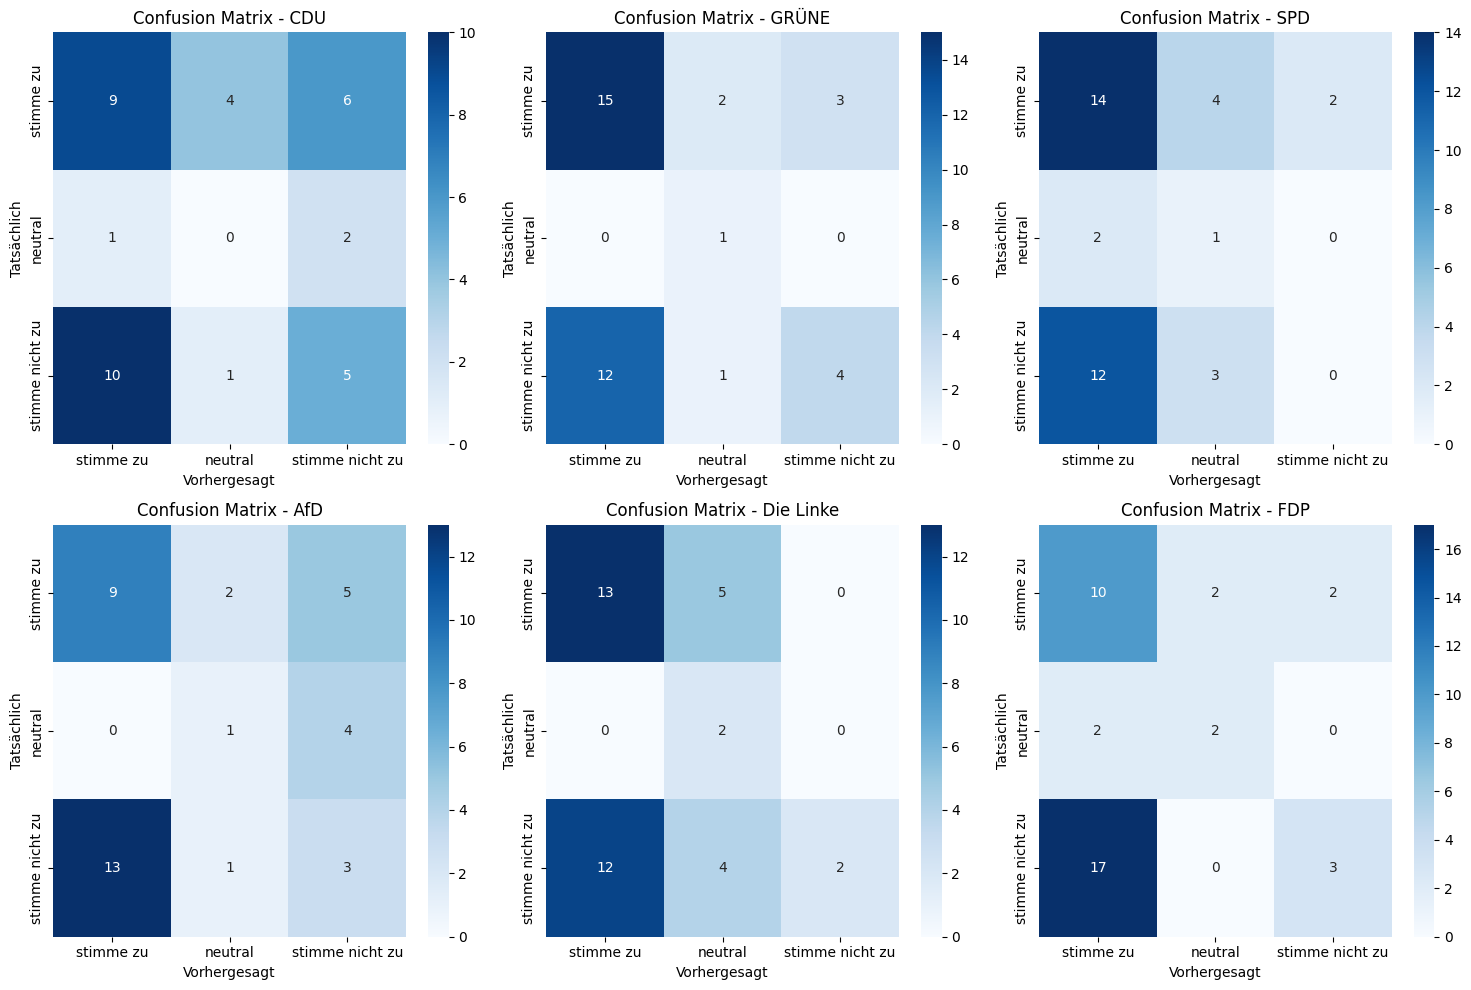

In [20]:
fig, axes = plt.subplots(2, 3, figsize=(15, 10))  # 2 Reihen, 3 Spalten für Parteien

for i, (party, model_col) in enumerate(party_model_mapping.items()):
    if model_col in df_comparison.columns:  
        # Erstellen der Confusion Matrix
        cm = confusion_matrix(df_comparison[party], df_comparison[model_col], labels=["stimme zu", "neutral", "stimme nicht zu"])
        
        # **Visualisierung der Confusion Matrix mit Seaborn**
        ax = axes[i // 3, i % 3]  # Positionierung im Grid
        sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=["stimme zu", "neutral", "stimme nicht zu"], 
                    yticklabels=["stimme zu", "neutral", "stimme nicht zu"], ax=ax)
        
        ax.set_title(f"Confusion Matrix - {party}")
        ax.set_xlabel("Vorhergesagt")
        ax.set_ylabel("Tatsächlich")

plt.tight_layout()

<Figure size 600x600 with 0 Axes>

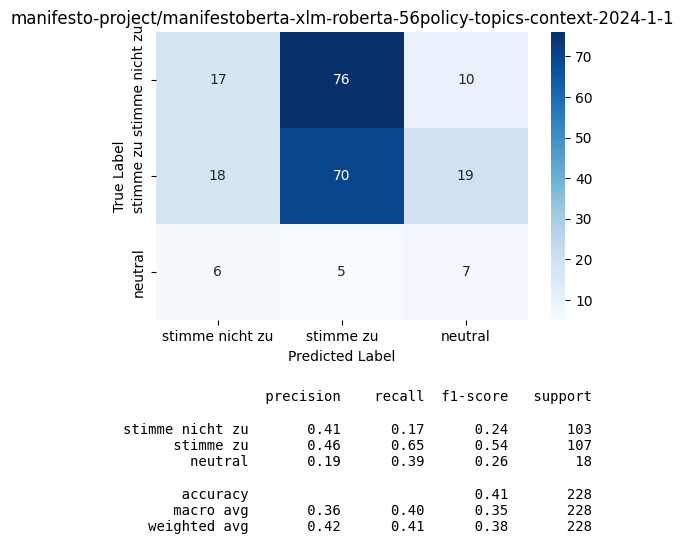

In [21]:
# Alle True Labels & Predictions für alle Parteien sammeln
true_labels = []
predicted_labels = []

for party, model_col in party_model_mapping.items():
    if model_col in df_comparison.columns:  
        true_labels.extend(df_comparison[party].tolist()) 
        predicted_labels.extend(df_comparison[model_col].tolist())

# Labels für die Confusion Matrix definieren
labels = ["stimme nicht zu", "stimme zu", "neutral"]

# Confusion Matrix berechnen
cm = confusion_matrix(true_labels, predicted_labels, labels=labels)

# Classification Report erstellen 
report_text = classification_report(true_labels, predicted_labels, labels=labels, target_names=labels)

accuracy = accuracy_score(true_labels, predicted_labels)
precision = precision_score(true_labels, predicted_labels, average="macro")
recall = recall_score(true_labels, predicted_labels, average="macro")
f1 = f1_score(true_labels, predicted_labels, average="macro")

# Confusion Matrix plotten
plt.figure(figsize=(6, 6))
fig, ax = plt.subplots(figsize=(6, 6))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=labels, yticklabels=labels, ax=ax)

ax.set_xlabel("Predicted Label")
ax.set_ylabel("True Label")
plt.title(f"{model_name}")

plt.gcf().text(0.07, 0.15, report_text, fontsize = 10, ha="left", va="center", family="monospace")
plt.subplots_adjust(bottom=0.4)

plt.show()

In [25]:
# modellergebnisse an gemeinsames Format anpassen 
model_prediction_scores = pd.DataFrame(
    [["manifestoberta-xlm-roberta-56policy-topics-context", "These", "These", "class prefitted", accuracy, precision, recall, f1]],
    columns=['model', 'lable_text_column', 'party_text_column', 'Manifesto_sorted', 'accuracy', 'precision', 'recall', 'f1']
)

# Ergebnisse als pkl speichern
with open("Model_prediction_scores.pkl", "wb") as f:
    pickle.dump(model_prediction_scores, f)